#**ASSIGNMENT 3: CONVOLUTIONAL NEURAL NETWORKS USING KERAS**

------------------------------------------
Student Name: Varshitha Venkatesh

A\#: 

e-mail: 

-----------------------------------------

This assignment focuses on developing two distinct convolutional neural networks (CNNs) for handwritten digit recognition. You will be tackling a multi-classification problem, where the neural network models will classify 28x28 pixel images of handwritten digits into one of 10 classes (0-9) representing digits 0 to 9.

The project utilizes the MNIST dataset [1] (https://yann.lecun.com/exdb/mnist/), a widely-used benchmark in machine learning and computer vision. This dataset consists of 60,000 training images and 10,000 test images, providing a robust foundation for training and evaluating your models.

You will implement the CNN models using TensorFlow's Keras API [4] (https://keras.io/about/), which offers a high-level, user-friendly interface for building neural networks.  Through this process, you will gain hands-on experience in:

* Designing and constructing CNN architectures using `keras` API of TensorFlow.
* Working with image data in machine learning contexts.
* Implementing multi-class classification models.
* Implementation of existing architectures, e.g., LeNet (Lecun et al. 1998) and Mini VGGNet model for digit recognition.
* Setting various hyperparameters of your CNN for its training.
* Training and evaluating neural networks on a standard dataset.

There are **four activities** and **two questions** for you to complete. You are expected to complete the first activity in this (Oct 23) recitation. You can comiplete the actaivities related to miniVGG in the next recitation. Please use Lecture slides 12-14 for your reference.

**Due date:** *Please include your last name in the .ipynb file and submit the renamed file to Teams by* **November 6.** *For instance, a student with the last name 'abc' would rename their file to Binary_classifier_activities_abc.ipynb.* Your submision notebook must have all the cells executed and the outputs displayed.

Let's get started!

As ussual, before executing the following python code, you have to upload the `Digit_Recognition` folder to your Google drive. Download the project from MS Teams and upload it into the `My Drive/Colab Notebooks` of your google drive.Then mount the google drive and set the working directory to `My Drive/Colab Notebooks/Digit_Recognition`.

In [1]:
import os
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
root_dir = "/content/gdrive/MyDrive/"
project_folder = "Colab Notebooks/Digit_Recognition/"
os.chdir(root_dir+project_folder)

Mounted at /content/gdrive


First, let us import some essential libraries and functions (including the optimizer (`SGD`), dataset (`MNIST`)) needed for our project. We will use functions from  `keras` and `sklearn` libraries. `Keras` (https://keras.io/) is a deep learning API written in Python, running on top of the machine learning platform TensorFlow.

In [2]:
# import the necessary packages
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
import numpy as np

# **1. Data Loading and Pre-processing**
For our digit recognition model, we will utilize the MNIST dataset, which stands for the Modified National Institute of Standards and Technology dataset. This dataset comprises 60,000 grayscale images of handwritten digits, each measuring 28×28 pixels. The images represent single digits ranging from 0 to 9. Below, you can see some examples of these images.





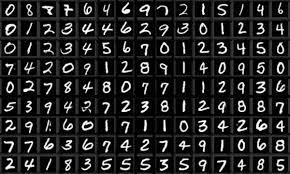

The MNIST dataset presents a fundamental image classification challenge: to accurately categorize handwritten digit images into their corresponding numerical values from 0 to 9. This dataset has become a cornerstone in the machine learning community, serving as a well-established benchmark for image recognition algorithms.

Given its extensive use and thorough analysis over the years, MNIST is largely considered a "solved" problem in the field. State-of-the-art models, primarily leveraging deep learning convolutional neural networks, have achieved remarkable performance on this task. These top-tier models consistently demonstrate classification accuracies exceeding 99% on the dataset.

The current benchmark for MNIST classification is exceptionally high, with the best-performing models achieving error rates as low as 0.2% to 0.4% on the held-out test set. This level of accuracy underscores the sophistication of modern machine learning techniques in tackling handwritten digit recognition.

### **1.1 Load the Data**
Let us first download the MNIST dataset from the Keras API. You can use the `load_data()` function from `mnist` for this purpose. The function loads training data, test data and the labels to the respective arrays.

In [3]:
# ------ Import the dataset
print("[INFO] accessing MNIST Dataset...")
((trainData, trainLabels), (testData, testLabels)) = mnist.load_data()

[INFO] accessing MNIST Dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Now let us check the shapes of the loaded data and visualize them to better understand its content.

Train: Images=(60000, 28, 28), Labels=(60000,)
Test: Images=(10000, 28, 28), Labels=(10000,)


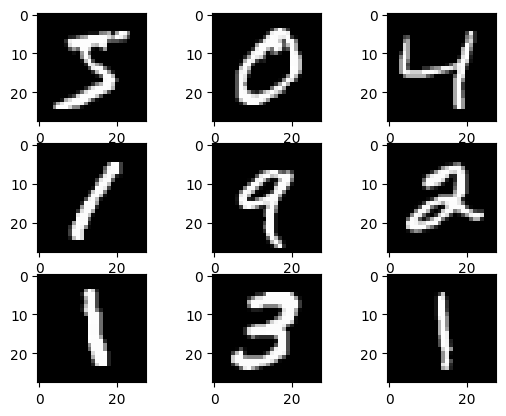

In [4]:
# summarize loaded dataset
print('Train: Images=%s, Labels=%s' % (trainData.shape, trainLabels.shape))
print('Test: Images=%s, Labels=%s' % (testData.shape, testLabels.shape))
# plot first few images
for i in range(9):
	# define subplot
	plt.subplot(330 + 1 + i)
	# plot raw pixel data
	plt.imshow(trainData[i], cmap=plt.get_cmap('gray'))
# show the figure
plt.show()

As you can see there as 60,000 labelled training data and 10,000 testing data inside the MNIST dataset.

Now let us verify the compatibility of input image shapes with the Keras backend (`K`) by determining whether the shape is in the format (width x height x channels) or (channels x width x height). If the depth (number of channels) is not expressed as the last dimension, reshape both the training and test datasets accordingly. The following code snippet implements this check and ensures that the data is properly formatted to meet Keras requirements, with channels positioned as the last dimension.

In [5]:
# ------ Verify data channel order - channels first
if K.image_data_format() == "channels_first":
	trainData = trainData.reshape((trainData.shape[0], 1, 28, 28))
	testData = testData.reshape((testData.shape[0], 1, 28, 28))

# ------ Channels last
else:
	trainData = trainData.reshape((trainData.shape[0], 28, 28, 1))
	testData = testData.reshape((testData.shape[0], 28, 28, 1))


### **1.2 Normalize the Data**
Next, let us normalize the images of the dataset. Main purpose of normalization is to make computation efficient by reducing the pixel values to 0 to 1. Normalization also calibrate the different pixels intensities into a normal distribution which makes the image looks better for the visualizer. We use `float32` data type to represent the values for efficiency reasons. No need to allocate longer data type, e.g., `float64`.


In [6]:
# ------ normalize the inputs
trainData = trainData.astype("float32") / 255.0
testData = testData.astype("float32") / 255.0

To properly train and test our neural network model, we need to convert our integer labels into a format suitable for multi-class classification. This process is known as label encoding or one-hot encoding.

In multi-class classification, the network essentially performs binary classification for each class. This means we need to transform our single-column integer labels into a matrix where each row represents a sample, and each column represents a class. For each sample, the column corresponding to its class will have a value of 1, while all other columns will be 0.
For example, if we have 5 classes (0, 1, 2, 3, 4), a label of 2 would be transformed into [0, 0, 1, 0, 0].

This conversion serves several purposes:

* It eliminates any implied ordinal relationship between classes.
* It allows the network to output probabilities for each class independently.
* It enables the use of categorical cross-entropy loss function, which is common in multi-class classification problems.

Fortunately, scikit-learn's LabelBinarizer class simplifies this process. The transform() method of LabelBinarizer automatically creates a binary matrix from our integer labels. Each column in this matrix corresponds to a unique class, and each row represents a sample. The value 1 in a row indicates the class to which the sample belongs, while 0s indicate the classes to which it doesn't belong.

By using LabelBinarizer, we ensure our labels are in the correct format for training our model and evaluating its performance across all classes simultaneously.

In [7]:
# ------ convert the labels from integers to column vectors
label_binarizer = LabelBinarizer()
trainLabels = label_binarizer.fit_transform(trainLabels)
testLabels = label_binarizer.transform(testLabels)

# **2. Build and Train the LeNet Model (25%)**

Lenet-5 (discussed in Lect. 12) is one of the earliest pre-trained models proposed by Yann LeCun and others in the year 1998, in the research paper Gradient-Based Learning Applied to Document Recognition. They used this architecture for recognizing the handwritten and machine-printed characters. The LeNet architecture is an excellent “first architecture” for Convolutional Neural Networks (especially when trained on the MNIST dataset, an image dataset for handwritten digit recognition).

LeNet is small and easy to understand — yet large enough to provide interesting results. Furthermore, the combination of LeNet + MNIST is able to run on the CPU, making it easy for beginners to take their first step in Deep Learning and Convolutional Neural Networks. The architecture diagram and the layerwise descriptions are given below.




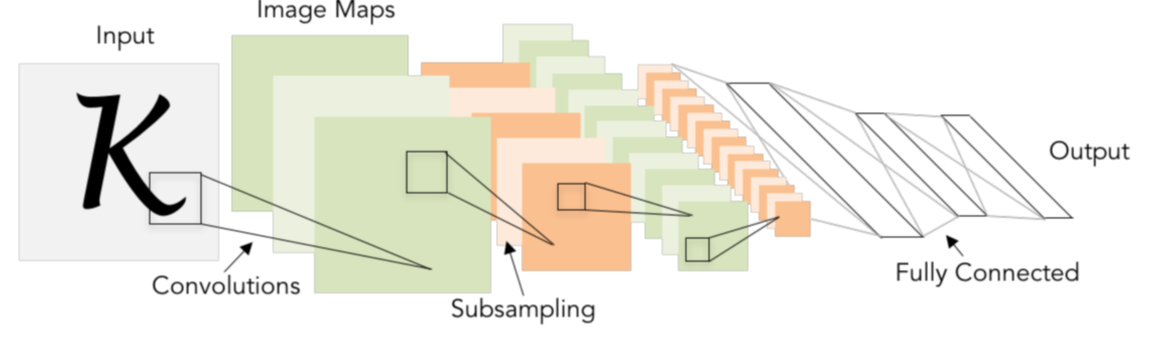

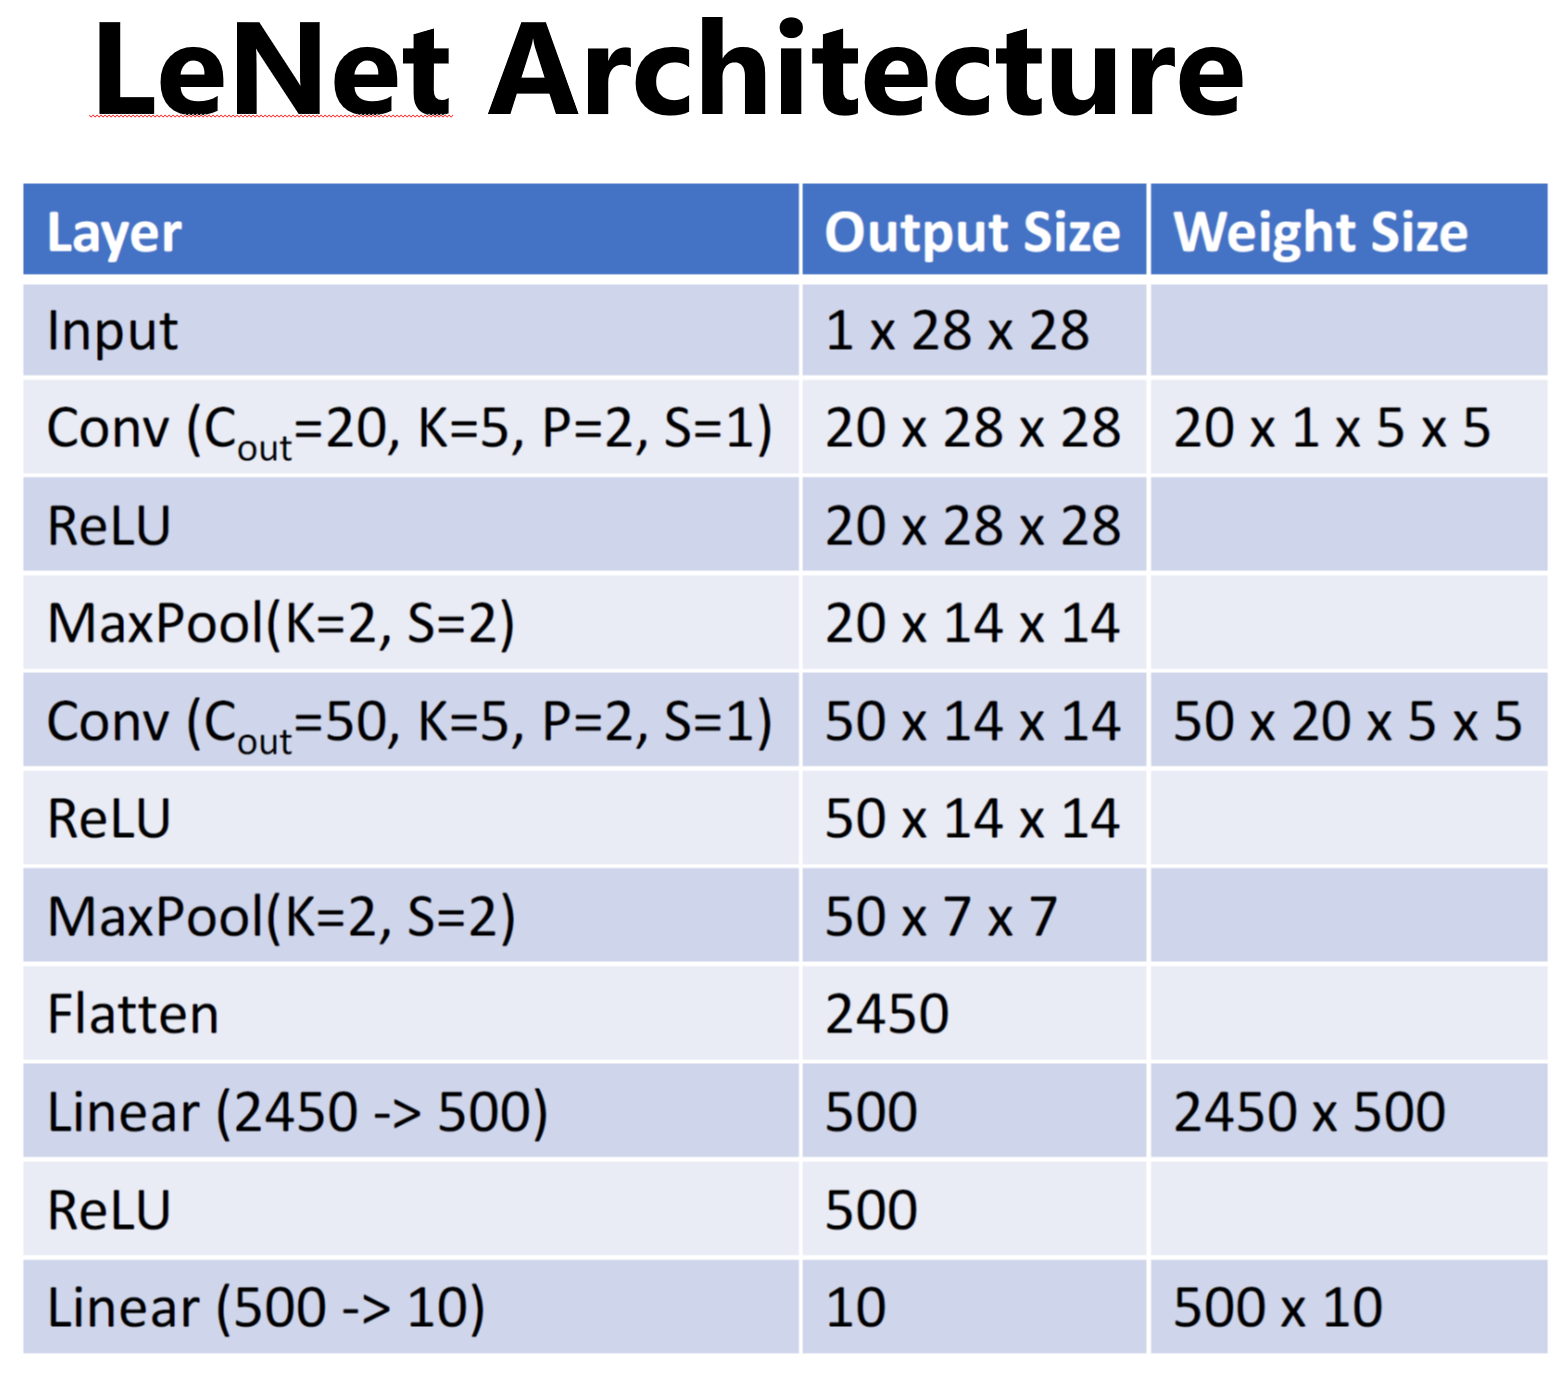

Keras provides a rich set of layers for building neural networks. Here's an overview of some key layers and their syntaxes (refer to Lect. 13 and  https://www.tensorflow.org/api_docs/python/tf/keras/layers ):

* Sequential:
The Sequential model is a linear stack of layers. It's the simplest way to build a neural network. For example.
```
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])
```
* Dense: The Dense layer is a fully connected layer. It's defined as:
```
layers.Dense(units, activation=None, use_bias=True)
```
Where `units` is the number of neurons in the layer.

* Conv2D: Conv2D is a 2D convolution layer. It's commonly used for image processing:
```
layers.Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', activation=None)
```
Key parameters include `filters` (number of output filters) and `kernel_size` (size of the convolution kernel)

* MaxPooling2D: MaxPooling2D performs max pooling operation for spatial data. It's often used to reduce the spatial dimensions of the input.
```
layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding='valid')
```
* Flatten: Flatten layer flattens the input without affecting the batch size. It's commonly used to transition from convolutional layers to dense layers.
```
layers.Flatten()
```


Now, let us build the LeNet model as described above. We have filled out the first [Conv, ReLU, Pool] part for you. Your task is to replicate [Conv, ReLU, Pool] part with appropriate arguments used in the LeNet architecture (See the above table to get the argument values)

In [8]:
# import the necessary packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras import backend as K

class LeNet:
    @staticmethod
    def build(width, height, depth, classes):
        # initialize the model
        model = Sequential()

        # if we are using "channels first", update the input shape
        if K.image_data_format() == "channels_first":
            inputShape = (depth, height, width)
        else:
            inputShape = (height, width, depth)

        model.add(Input(shape=inputShape))

        # first set of CONV => RELU => POOL layers
        model.add(Conv2D(20, (5, 5), padding="same"))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

        # second set of CONV => RELU => POOL layers
        model.add(Conv2D(50, (5, 5), padding="same"))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

        # first (and only) set of FC => RELU layers
        model.add(Flatten())
        model.add(Dense(500))
        model.add(Activation("relu"))

        # softmax classifier
        model.add(Dense(classes))
        model.add(Activation("softmax"))

        # return the constructed network architecture
        return model

The following code first builds the LeNet model using the `build()` function that you just completed. It then configures the model using the stochastic gradient descent (SGD) optimizer and categorical cross-entropy loss function. It is important to note that the learning rate and choice of optimization algorithm are hyperparameters that can be adjusted to improve model performance.

For the initial learning rate, you may experiment with different values, such as 0.0003, to find the optimal setting for your specific problem. Additionally, TensorFlow's Keras API offers a variety of alternative optimizers that you might consider trying, including `adam`, `adagrad`, `RMSprop`, `adadelta` (refer to Lect. 9) etc. These are already provided by `tf.keras.optimizers` (https://www.tensorflow.org/api_docs/python/tf/keras/optimizers), allowing for easy implementation and comparison of different optimization techniques.


In [9]:
# ------ initialize the optimizer and model
print("[INFO] compiling model...")
opt = SGD(learning_rate = 0.01)
model = LeNet.build(width=28, height=28, depth=1, classes=10)
model.compile(loss="categorical_crossentropy", optimizer=opt,
	metrics=["accuracy"])


[INFO] compiling model...


Now let us train the model for 20 epochs with a batch size of 128. Some of the hyperparameters that you may try modifying here are: `batch_size` (32/64), `epochs` (<40 or >40). Each time you modify the parameters, verify the changes in the accuracy of the model on training data and validation data. Training is done using the `fit()` function.

In [10]:
# ------ training
print("[INFO] training network...")
H = model.fit(trainData, trainLabels,
	validation_data=(testData, testLabels), batch_size=128,
	epochs=40, verbose=1)

[INFO] training network...
Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5864 - loss: 1.5875 - val_accuracy: 0.8948 - val_loss: 0.3479
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9137 - loss: 0.2942 - val_accuracy: 0.9422 - val_loss: 0.1971
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9397 - loss: 0.2017 - val_accuracy: 0.9407 - val_loss: 0.1896
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9544 - loss: 0.1518 - val_accuracy: 0.9641 - val_loss: 0.1169
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9636 - loss: 0.1246 - val_accuracy: 0.9684 - val_loss: 0.1058
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9693 - loss: 0.1066 - val_accuracy: 0.9744 - val_loss: 0.0863
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9736 - loss: 0.0910 - val_accuracy: 0.9747 - val_loss: 0.0826
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9750 - loss

Keeping the default parameters, after training for 40 epochs, the trainig accuracy should be somewhere around 99.48% for this model. The validation accuracy will be ~98.94%.

In [11]:
# save the network to disk
print("[INFO] serializing network...")
model.save("./model.keras")
print(model.summary())

[INFO] serializing network...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 20)          │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 20)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 50)          │          25,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 14, 14, 50)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 50)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2450)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 500)                 │       1,225,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,256,082 (4.79 MB)

 Trainable params: 1,256,080 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


# **3. Evaluate the Model**
Once you have built your model, the most important question that arises is how good is your model? So, evaluating your model is the most important task after training which quantitatively delineates how good your predictions are.

This code snippet below is using the `classification_report` function from `scikit-learn` to evaluate the performance of a machine learning model. Let's break it down:

* `predictions = model.predict(testData, batch_size=128)`:
This line generates predictions using the trained model on the test data. The batch_size parameter is set to 128, which means the predictions are made in batches of 128 samples at a time1.

* `classification_report() function`:
This function computes various classification metrics and presents them in a formatted string2. It takes the following arguments:

`testLabels.argmax(axis=1)`: This converts the one-hot encoded true labels back to class indices.

`predictions.argmax(axis=1)`: This converts the predicted probabilities to class indices by selecting the index with the highest probability for each sample.

`target_names=[str(x) for x in label_binarizer.classes_]`: This provides human-readable names for the classes.


The classification_report will output a table with the following metrics for each class. To quantify our model performance, we will use the following scores.

* **Precision**: Precision is the ratio of correctly predicted positive observations to the total predicted positive observations. Precisely, precision quantifies the number of positive class predictions that actually belong to the positive class.

* **Recall** (Sensitivity) - Recall is the ratio of correctly predicted positive observations to the all observations in actual class. Recall attempts to answer the following question: "What proportion of actual positives was identified correctly?"

* **F1 score** - F1 Score is the weighted average of Precision and Recall. Therefore, this score takes both false positives and false negatives into account. Intuitively it is not as easy to understand as accuracy, but F1 is usually more useful than accuracy, especially if you have an uneven class distribution. Accuracy works best if false positives and false negatives have similar cost. If the cost of false positives and false negatives are very different, it is better to look at both Precision and Recall.

* **Support** The number of samples for each class in the test set.



 Now let us evaluate the trained model with the default function (classification_report) provided by the sklearn library.

In [12]:
# ----- evaluate the network
print("[INFO] evaluating network...")
predictions = model.predict(testData, batch_size=128)
print(classification_report(testLabels.argmax(axis=1),
	predictions.argmax(axis=1),
	target_names=[str(x) for x in label_binarizer.classes_]))

[INFO] evaluating network...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       1.00      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Next, plot the loss and accuracy curve to see how the training progressed.

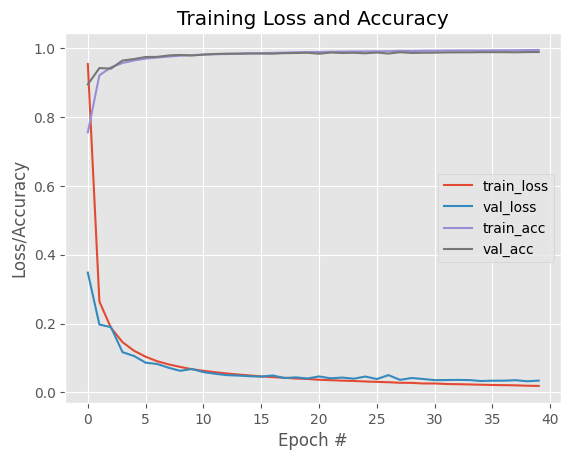

In [13]:
# ----- plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 40), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 40), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 40), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 40), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()


Now let us test our model with some images and check its prediction. We have provided some test images under the `data` folder. Use your trained LeNet model to predict the digit shown in the images.

The following code defines a function `load_image` that takes an image filename as input and processes it for use with the LeNet model trained on the MNIST dataset. It loads the image, converts it to grayscale, resizes it to 28x28 pixels, displays it using matplotlib, converts it to a NumPy array, reshapes it to match the input shape expected by the model (1, 28, 28, 1), and normalizes the pixel values to a range of 0 to 1. The function returns this processed image, ready to be fed into the LeNet model for prediction. The code also imports necessary functions from NumPy, Keras, and TensorFlow libraries to support these operations.

In [14]:
# make some necessary import.
from numpy import argmax
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.models import load_model

# load and prepare the image
def load_image(filename):
	# load the image
	img = load_img(filename, color_mode="grayscale", target_size=(28, 28))
	# convert to array
	plt.imshow(img)
	img = img_to_array(img)
	# reshape into a single sample with 1 channel
	img = img.reshape(1, 28, 28, 1)
	# prepare pixel data
	img = img.astype('float32')
	img = img / 255.0
	return img

Next we use a function `run_test()` that demonstrates how to use a pre-trained machine learning model to classify a handwritten digit image. It first calls the previously defined `load_image()` function to load and preprocess an image of a digit (in this case, '9.jpg' from the './data/' directory). The processed image is then fed into a pre-trained model (assumed to be stored in the variable model) using the predict() method. The prediction result is a probability distribution over the possible digits (0-9). The `argmax()` function is used to find the index of the highest probability, which corresponds to the predicted digit. Finally, the predicted digit is printed to the console. The `run_test()` function is then called, serving as the entry point to execute this classification process.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
The digit in the given image is: 2


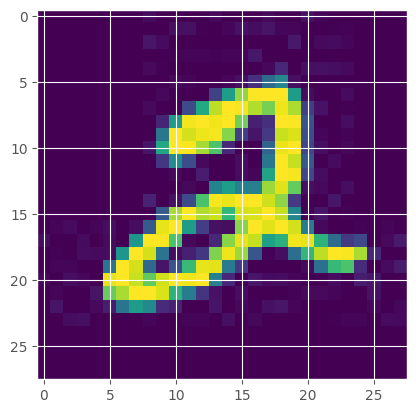

In [16]:
# load an image and predict the class
def run_test():
	# load the image. You can try out different digits in [0,9]. We have providede one instance of each digit.
	img = load_image('./data/2.jpg')
	# predict the class
	predict_value = model.predict(img)
	digit = argmax(predict_value)
	print("The digit in the given image is: "+str(digit))

# entry point, run the example
run_test()

Great job! You've successfully implemented your first CNN in this course using the TensorFlow Keras library.

# **4. Build and Train a Mini-VGG model (50%)**

In our previous model, we built LeNet, a seminal Convolutional Neural Network in the deep learning and computer vision literature. In the second part of this project, we will build VGGNet. VGGNet, (sometimes referred to as simply VGG), was first introduced by Simonyan and Zisserman in their 2014 paper, "Very Deep Learning Convolutional Neural Networks for Large-Scale Image Recognition"[2]. The primary contribution of their work was demonstrating that an architecture with very small (3×3) filters can be trained to increasingly higher depths (16-19 layers) and obtain state-of-the-art classification on the challenging classification task.

Training the entire 16 and 19 layer variants of VGGNet may expand beyond the scope of this project. Therefore, we will implement a smaller version of VGGNet called MiniVGGNet that can easily be trained here in Colab.

Overall, MiniVGGNet consists of two sets of CONV => RELU => CONV => RELU => POOL layers, followed by a set of FC => RELU => FC => SOFTMAX layers. The first two CONV layers will learn 32 filters, each of size 3×3. The second two CONV layers will learn 64 filters, again, each of size 3×3. Our POOL layers will perform max pooling over a 2×2 window with a 2×2 stride. We’ll also be inserting batch normalization layers after the activations along with dropout layers (DO) after the POOL and FC layers. The model is summarized in Figure 2 below.

 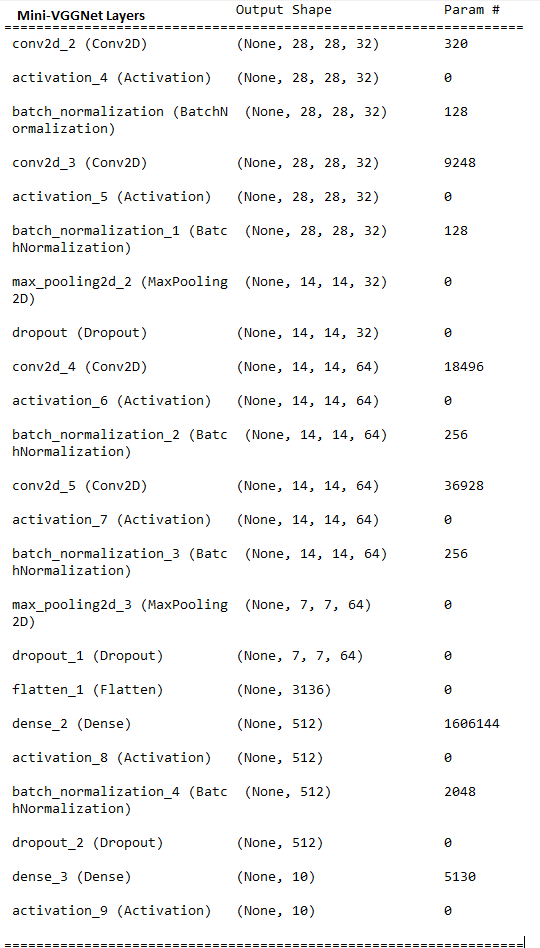


By this time, you already got an opportunity to build a CNN using different layer instances available in `keras`. So now your task is to build the model as per the descriptions provided above. We have completed some parts of the code for your reference.

In [17]:
#Graded Activity: 2 (25%)

#import two important layers from keras required this model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout

class MiniVGGNet:
    @staticmethod
    def build(width, height, depth, classes):
        # initialize the model along with the input shape to be
        # "channels last" and the channels dimension itself
        model = Sequential()
        inputShape = (height, width, depth)
        chanDim = -1

        # if we are using "channels first", update the input shape
        # and channels dimension
        if K.image_data_format() == "channels_first":
            inputShape = (depth, height, width)
            chanDim = 1

        # first CONV => RELU => CONV => RELU => POOL layer set
        model.add(Conv2D(32, (3, 3), padding="same", input_shape=inputShape))
        model.add(Activation("relu"))
        model.add(BatchNormalization(axis=chanDim))
        model.add(Conv2D(32, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(BatchNormalization(axis=chanDim))
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))

        # second CONV => RELU => CONV => RELU => POOL layer set
        model.add(Conv2D(64, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(BatchNormalization(axis=chanDim))
        model.add(Conv2D(64, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(BatchNormalization(axis=chanDim))
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))

        # first (and only) set of FC => RELU layers
        model.add(Flatten())
        model.add(Dense(512))
        model.add(Activation("relu"))
        model.add(BatchNormalization())
        model.add(Dropout(0.5))

        # softmax classifier
        model.add(Dense(classes))
        model.add(Activation("softmax"))

        # return the constructed network architecture
        return model

Compile the new Mini-VGGNet model just like what you did before. However, instead of `SGD` optimizer, use `Adam` (https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) and `categorical_crossentropy` loss function.

In [18]:
#Graded Activity: 3 (20%)

# ------ initialize the optimizer and model
from tensorflow.keras.optimizers import Adam

print("[INFO] compiling model-2...")
opt2 = Adam()  # Adam optimizer
model2 = MiniVGGNet.build(width=28, height=28, depth=1, classes=10)

# Use the categorical cross-entropy loss and adam optimizer
model2.compile(loss="categorical_crossentropy", optimizer=opt2, metrics=["accuracy"])

[INFO] compiling model-2...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train the second model using a `batch_size` of 64 and 20 `epochs`. Note that `verbose` can take different values such as 0, 1 or 2. We recommend using the value 1 to get the details of the training. A vale of 0 will show nothing and a value of 2 will show the details without the progress bar. After 20 epochs, you will see an accuracy of ~99.11% and a validation accuracy of ~99.45% (This may not be the exact values that you will be getting, that is okay).

In [19]:
#Graded Activity: 4 (15%)
# ------ training
print("[INFO] training 2nd network...")
H = model2.fit(trainData, trainLabels,
	validation_data=(testData, testLabels), batch_size=32,
	epochs=20, verbose=1)

[INFO] training 2nd network...
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9172 - loss: 0.2716 - val_accuracy: 0.9878 - val_loss: 0.0398
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9776 - loss: 0.0702 - val_accuracy: 0.9863 - val_loss: 0.0401
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9821 - loss: 0.0574 - val_accuracy: 0.9900 - val_loss: 0.0338
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9843 - loss: 0.0486 - val_accuracy: 0.9909 - val_loss: 0.0281
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9869 - loss: 0.0417 - val_accuracy: 0.9919 - val_loss: 0.0238
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9899 - loss: 0.0339 - val_accuracy: 0.9933 - val_loss: 0.0223
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9901 - loss: 0.0332 - val_accuracy: 0.9926 - val_loss: 0.0248
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step 

In [20]:
# save the network to disk
print("[INFO] serializing 2nd network...")
model2.save("./model2.keras")

[INFO] serializing 2nd network...


Let's now move on to a quantitative evaluation of our model. We'll assess its performance using precision, recall, and F1 score metrics, similar to our previous analysis with LeNet.

In [21]:
# ----- evaluate the network
print("[INFO] evaluating 2nd network...")
predictions2 = model2.predict(testData, batch_size=128)
print(classification_report(testLabels.argmax(axis=1),
	predictions2.argmax(axis=1),
	target_names=[str(x) for x in label_binarizer.classes_]))

[INFO] evaluating 2nd network...
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       1.00      0.99      0.99       982
           5       0.99      1.00      1.00       892
           6       1.00      0.99      1.00       958
           7       1.00      0.99      0.99      1028
           8       1.00      1.00      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       1.00      0.99      0.99     10000
weighted avg       1.00      0.99      0.99     10000



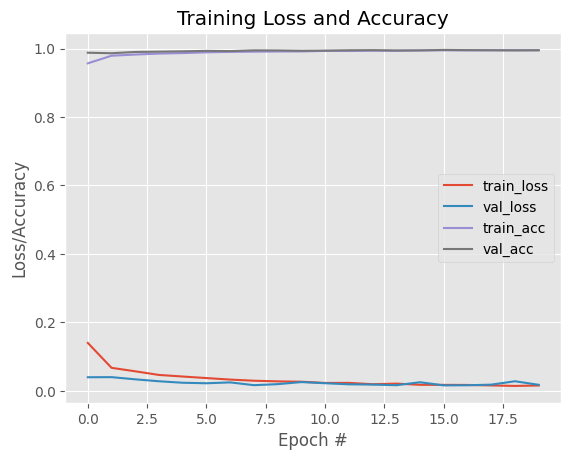

In [22]:
# ----- plot the training loss and accuracy
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()


Test the Mini-VGGNet using some sample images uploaded to `data` folder. Verify the results.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
The digit in the given image is: 8


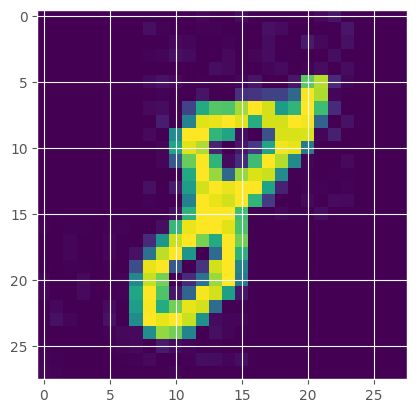

In [24]:
def run_test2():
	# load the image
	img = load_image('./data/8.jpg')
	# predict the class
	predict_value = model2.predict(img)
	digit = argmax(predict_value)
	print("The digit in the given image is: "+str(digit))

# entry point, run the example
run_test2()

**Well done!** You have now implemented two convolution neural networks. We recommend you to try out different values for the hyperparameters and analyze how the tuning affects the predictions.

**Training Without Batch Normalization**

In [25]:
# Training model3 Without Batch Normalization

class MiniVGGNet:
    @staticmethod
    def build(width, height, depth, classes):
        # initialize the model along with the input shape to be
        # "channels last" and the channels dimension itself
        model = Sequential()
        inputShape = (height, width, depth)
        chanDim = -1

        # if we are using "channels first", update the input shape
        # and channels dimension
        if K.image_data_format() == "channels_first":
            inputShape = (depth, height, width)
            chanDim = 1

        # first CONV => RELU => CONV => RELU => POOL layer set
        model.add(Conv2D(32, (3, 3), padding="same", input_shape=inputShape))
        model.add(Activation("relu"))
        model.add(Conv2D(32, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))

        # second CONV => RELU => CONV => RELU => POOL layer set
        model.add(Conv2D(64, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(Conv2D(64, (3, 3), padding="same"))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size=(2, 2)))
        model.add(Dropout(0.25))

        # first (and only) set of FC => RELU layers
        model.add(Flatten())
        model.add(Dense(512))
        model.add(Activation("relu"))
        model.add(Dropout(0.5))

        # softmax classifier
        model.add(Dense(classes))
        model.add(Activation("softmax"))

        # return the constructed network architecture
        return model

In [26]:
# compiling model3 without BN
print("[INFO] compiling model-2...")
opt2 = Adam()  # Adam optimizer
model3 = MiniVGGNet.build(width=28, height=28, depth=1, classes=10)

# Use the categorical cross-entropy loss and adam optimizer
model3.compile(loss="categorical_crossentropy", optimizer=opt2, metrics=["accuracy"])

[INFO] compiling model-2...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
# ------ training model3
print("[INFO] training 2nd network...")
H = model3.fit(trainData, trainLabels,
	validation_data=(testData, testLabels), batch_size=32,
	epochs=20, verbose=1)

[INFO] training 2nd network...
Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8981 - loss: 0.3138 - val_accuracy: 0.9890 - val_loss: 0.0337
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9821 - loss: 0.0610 - val_accuracy: 0.9899 - val_loss: 0.0297
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9858 - loss: 0.0469 - val_accuracy: 0.9921 - val_loss: 0.0232
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9890 - loss: 0.0355 - val_accuracy: 0.9921 - val_loss: 0.0237
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9904 - loss: 0.0311 - val_accuracy: 0.9892 - val_loss: 0.0324
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9915 - loss: 0.0286 - val_accuracy: 0.9929 - val_loss: 0.0224
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9917 - loss: 0.0259 - val_accuracy: 0.9943 - val_loss: 0.0208
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step 

In [29]:
# save the network to disk
print("[INFO] serializing 2nd network...")
model3.save("./model3.keras")

[INFO] serializing 2nd network...


In [30]:
# ----- evaluate the network
print("[INFO] evaluating 3rd network...")
predictions2 = model3.predict(testData, batch_size=128)
print(classification_report(testLabels.argmax(axis=1),
	predictions2.argmax(axis=1),
	target_names=[str(x) for x in label_binarizer.classes_]))

[INFO] evaluating 3rd network...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      1.00      1.00      1028
           8       0.99      1.00      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



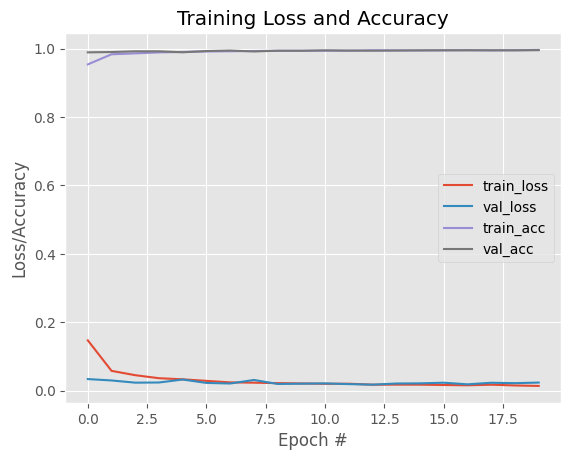

In [31]:
# ----- plot the training loss and accuracy for model3
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

#**6. Discussion (15%)**

**Question 1** How would you compare and interpret the loss curves of LeNet and miniVGG models trained on the MNIST dataset, and what insights can be gained about their learning dynamics and generalization performance (convergence speed, any signes of over/underfitting, impact of increased depth and parameters, architectural difference Vs accuracy etc.)? Please provide your discussion below.

**Answer**: In LeNet we can observe a high learning rate as the training and validation loss take a steep drop within the first very few epochs - this means that LeNet quickly learns features and brings down the overall loss. The miniVGG model takes a bit longer to reach some stability forr loss and accuracy, and we can observe a few spikes in the first few epochs which means that it takes a lot time to stabilize its loss.

**Question 2** How does the incorporation of batch normalization layers in the mini-VGG architecture affect its performance, and training dynamics in the context of MNIST digit classification? [Train the mini VGG model with and without BN and compile your answer based on the loss curves, timings, accuracies]

**Answer**: Since miniVGG is a deeper architecture, adding batch normalization will improve its performance for this classification. With batch normalization, the model will converge faster and it also helps stabilizing loss curve. This also means that the learning rate will increase and lowers the chances of overfitting, overall resulting in higher accuracy and faster training.

#**7. Evaluation Details**
The assignment will be discussed in the recitations on Oct 23 and Oct. 30. You will get a total of 16 days to complete the activities.  Attendance in each recitation is mandatory to get marks for the graded activities. We will record your attendance. If you complete all the activities in the first recitation itself, then the second recitation is optional. You have to read the instructions, refer to the slides and do all the exercises. The marker reserves the prerogative to pose supplementary questions for elucidation when deemed necessary.

**NOTE** If you are unable to attend the recitation, please notify the instructor prior to the session. Absences due to illness or other valid reasons will be taken into consideration.

#**8. References and Acknowledgements**
1. http://yann.lecun.com/exdb/mnist/
2. Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition. arXiv preprint arXiv:1409.1556.
3. LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. Proceedings of the IEEE, 86(11), 2278-2324.
4. https://keras.io/about/